# Lab 4 - part2
### Edge Detection

https://github.com/scikit-image/scikit-image/blob/master/skimage/filters/edges.py

http://scikit-image.org/docs/0.11.x/auto_examples/plot_edge_filter.html

http://scikit-image.org/docs/dev/auto_examples/edges/plot_canny.html



In [2]:
from commonfunctions import *
from skimage import io
from skimage.color import rgb2gray
from skimage import filters 
from skimage import feature

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
'''
1. Built-in Sobel, Prewill, Roberts, Canny
2. Custom Sobel (V-H-Both)
3. Custom LoG
'''

'\n1. Built-in Sobel, Prewill, Roberts, Canny\n2. Custom Sobel (V-H-Both)\n3. Custom LoG\n'

In [4]:
img = io.imread('circuit.tif')
img.ndim

2

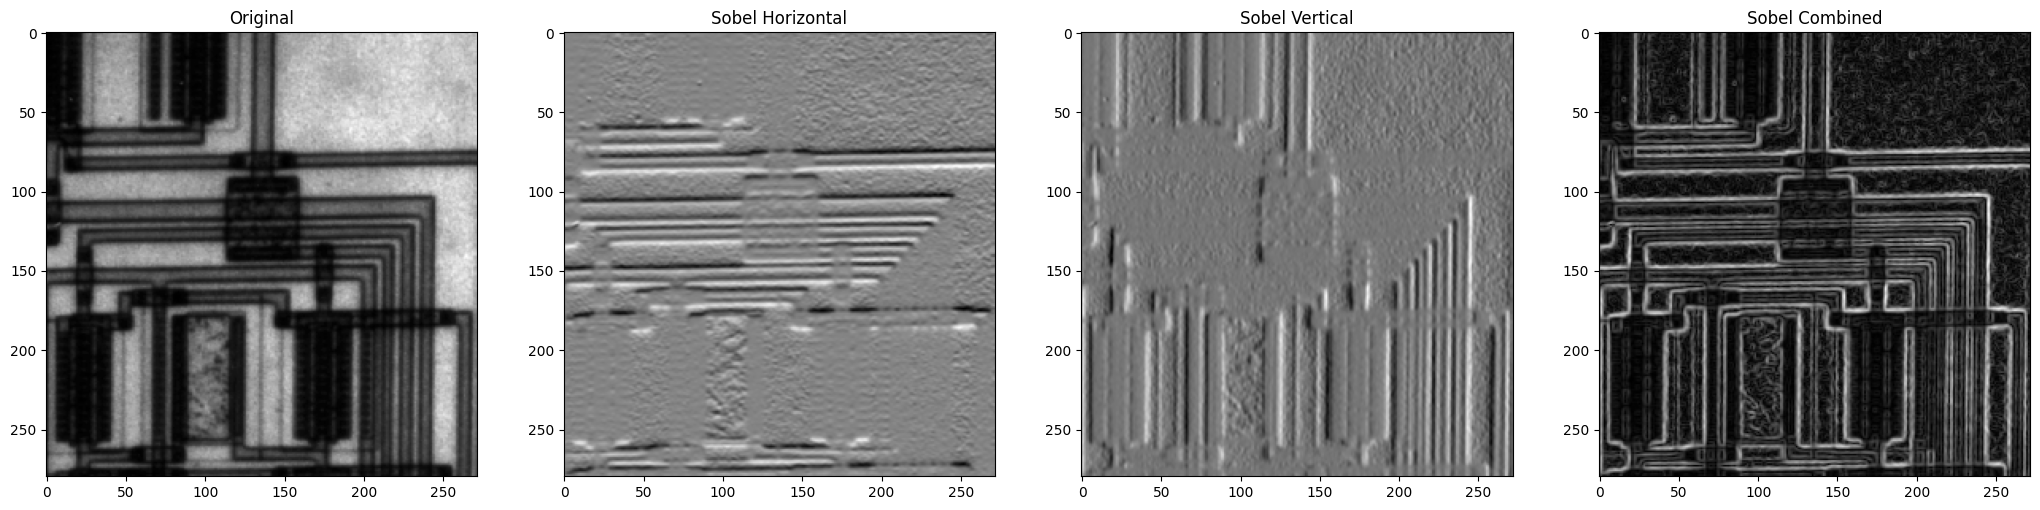

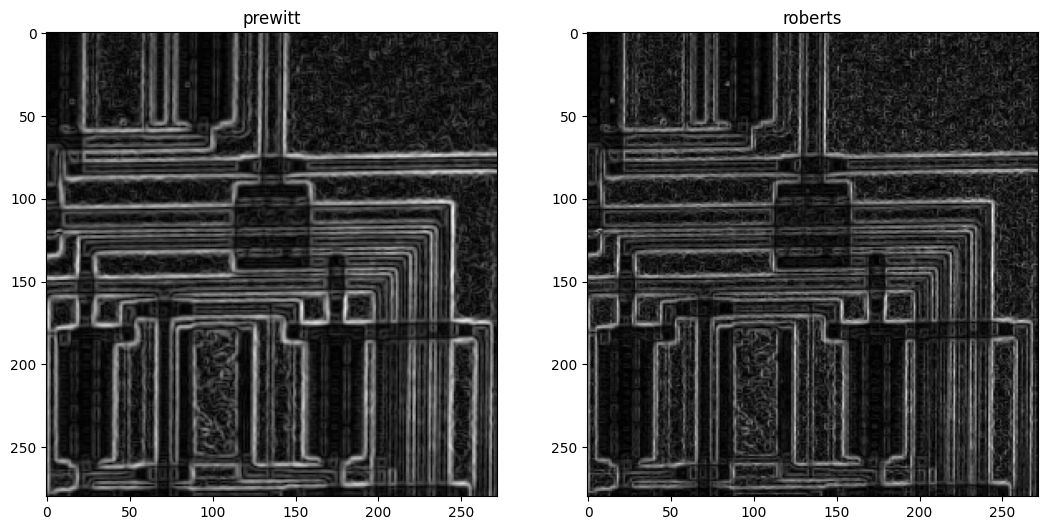

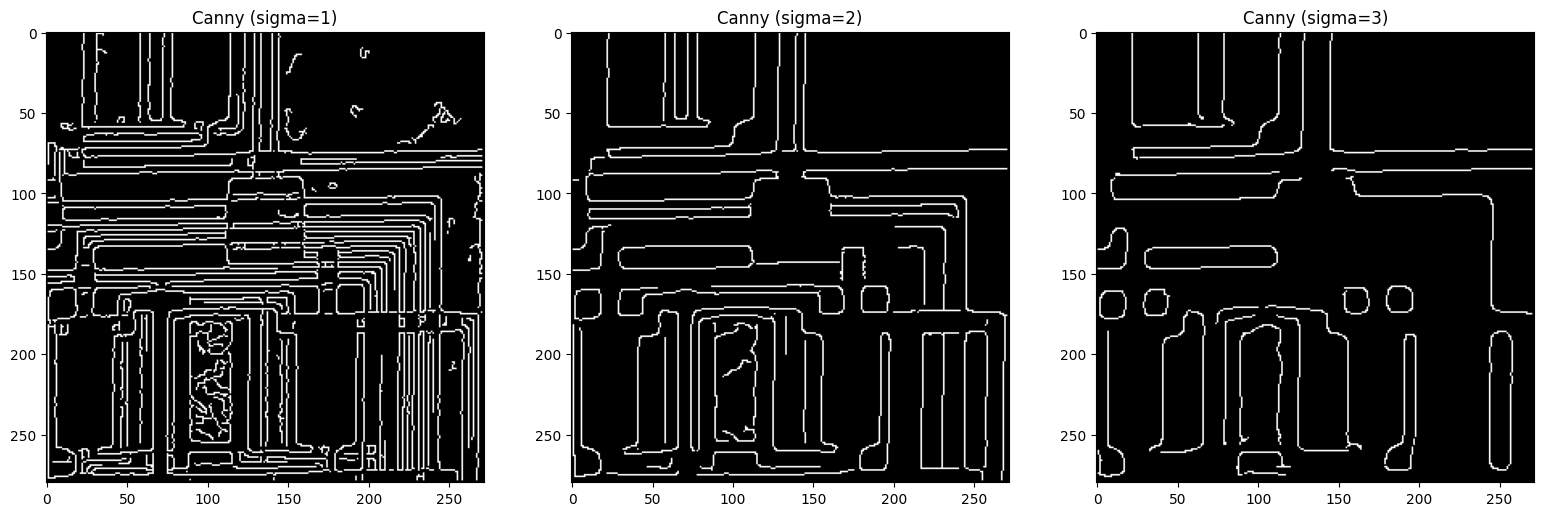

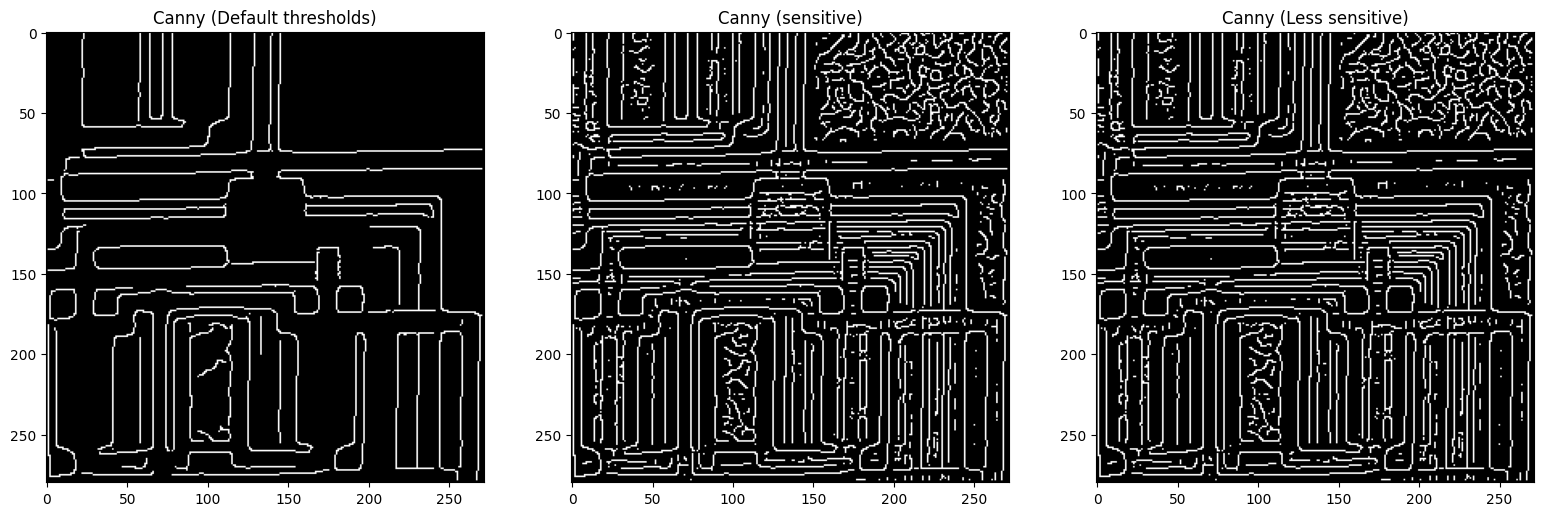

In [5]:
# 1. Built-in Sobel, Prewitt, Roberts, Canny

sobel_h = filters.sobel_h(img)
sobel_v = filters.sobel_v(img)
sobel = filters.sobel(img)
show_images([img, sobel_h, sobel_v, sobel], 
           ['Original', 'Sobel Horizontal', 'Sobel Vertical', 'Sobel Combined'])

prewitt_edges = filters.prewitt(img)
roberts_edges = filters.roberts(img)
show_images([prewitt_edges, roberts_edges],['prewitt','roberts'])

canny_sigma1 = feature.canny(img, sigma=1)
canny_sigma2 = feature.canny(img, sigma=2)
canny_sigma3 = feature.canny(img, sigma=3)
show_images([canny_sigma1, canny_sigma2, canny_sigma3], 
           ['Canny (sigma=1)', 'Canny (sigma=2)', 'Canny (sigma=3)'])

canny_default = feature.canny(img, sigma=2)
canny_sensitive = feature.canny(img, sigma=2, low_threshold=0.0261, high_threshold=0.0522)
canny_less_sensitive = feature.canny(img, sigma=2, low_threshold=0.8, high_threshold=0.9)
show_images([canny_default, canny_sensitive, canny_less_sensitive], 
           ['Canny (Default thresholds)', 'Canny (sensitive)', 'Canny (Less sensitive)'])

In [6]:
'''
Comparison 

SOBEL: First derivative operator
- sobel_h computes vertical gradient (y-direction) and highlights horizontal edges
- sobel_v computes horizontal gradient (x-direction) and highlights vertical edges
- noise sensitive

PREWITT: Like Sobel but with equal weights
- smoother in uniform areas, softer edge response

ROBERTS: Compact 2x2 diagonal kernels
- fast but noisy, good for sharp contrast

CANNY: Multi-stage algorithm (smoothing → gradient → suppression → thresholding → hysteresis)
- Sigma (0.5-3.0): Lower preserves details but doesn't elemenate noise
                 , higher reduces noise but increase blur
- Thresholds: lower for more edges, higher for fewer edges (supposedly)
- Provides thin, connected edges but more computationally intensive

'''

"\nComparison \n\nSOBEL: First derivative operator\n- sobel_h computes vertical gradient (y-direction) and highlights horizontal edges\n- sobel_v computes horizontal gradient (x-direction) and highlights vertical edges\n- noise sensitive\n\nPREWITT: Like Sobel but with equal weights\n- smoother in uniform areas, softer edge response\n\nROBERTS: Compact 2x2 diagonal kernels\n- fast but noisy, good for sharp contrast\n\nCANNY: Multi-stage algorithm (smoothing → gradient → suppression → thresholding → hysteresis)\n- Sigma (0.5-3.0): Lower preserves details but doesn't elemenate noise\n                 , higher reduces noise but increase blur\n- Thresholds: lower for more edges, higher for fewer edges (supposedly)\n- Provides thin, connected edges but more computationally intensive\n\n"

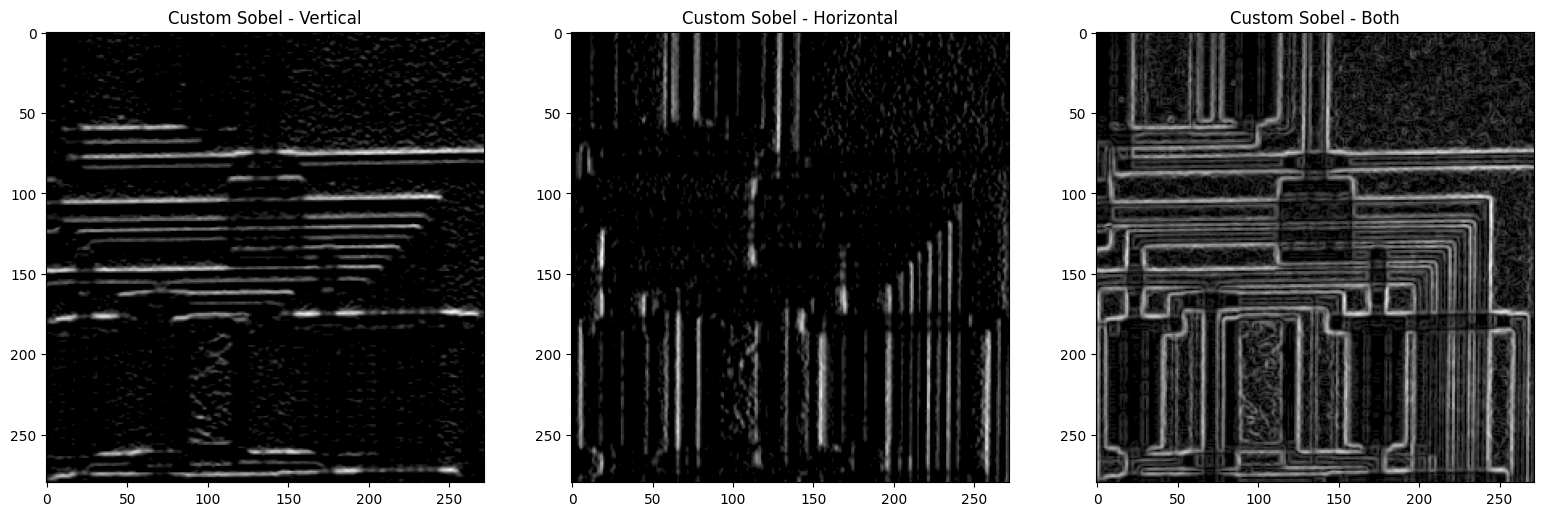

In [7]:
# 2. Custom Sobel (V-H-Both)

img = io.imread('circuit.tif', as_gray=True)
thres = 20

hx = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]])

hy = np.array([[-1,  0,  1],
               [-2,  0,  2],
               [-1,  0,  1]])

gx = convolve2d(img, hx, mode='same', boundary='symm')
gy = convolve2d(img, hy, mode='same', boundary='symm')

edge_strength = np.sqrt(gx**2 + gy**2)

gx_thresh = (gx > thres) * gx
gy_thresh = (gy > thres) * gy
edge_thresh = (edge_strength > thres) * edge_strength

show_images([gx_thresh, gy_thresh, edge_thresh],
            ['Custom Sobel - Vertical', 'Custom Sobel - Horizontal', 'Custom Sobel - Both'])






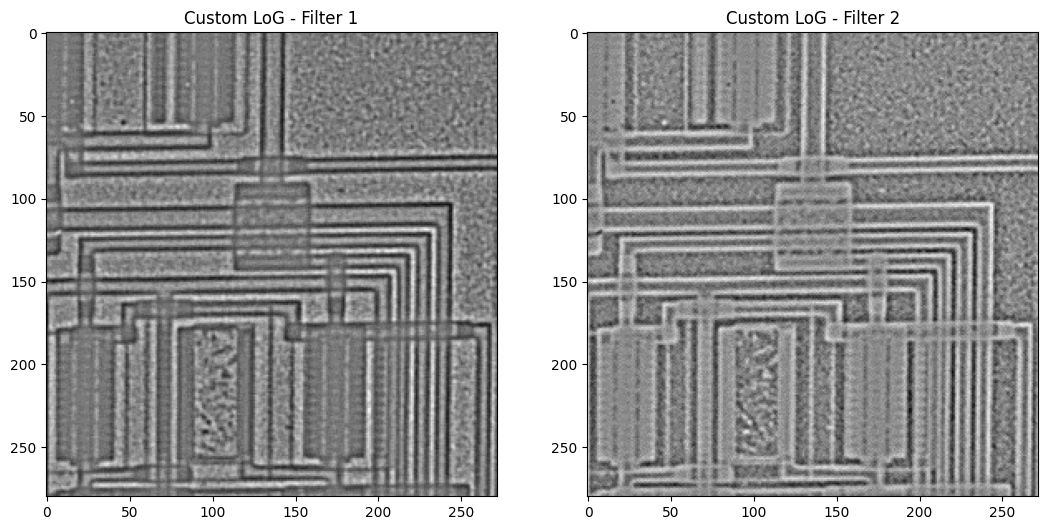

In [8]:
# 3. Custom LoG

from scipy.ndimage import gaussian_filter

smoothed = gaussian_filter(img, sigma=1)

f1 = np.array([[-1, -1, -1],
               [-1,  8, -1],
               [-1, -1, -1]])

f2 = np.array([[ 0,  1,  0],
               [ 1, -4,  1],
               [ 0,  1,  0]])

log1 = convolve2d(smoothed, f1, mode='same', boundary='symm')
log2 = convolve2d(smoothed, f2, mode='same', boundary='symm')

thres1 = 0.05 * np.max(np.abs(log1))
thres2 = 0.05 * np.max(np.abs(log2))

log1_thresh = np.where(np.abs(log1) > thres1, log1, 0)
log2_thresh = np.where(np.abs(log2) > thres2, log2, 0)

show_images([log1_thresh, log2_thresh], ['Custom LoG - Filter 1', 'Custom LoG - Filter 2'])




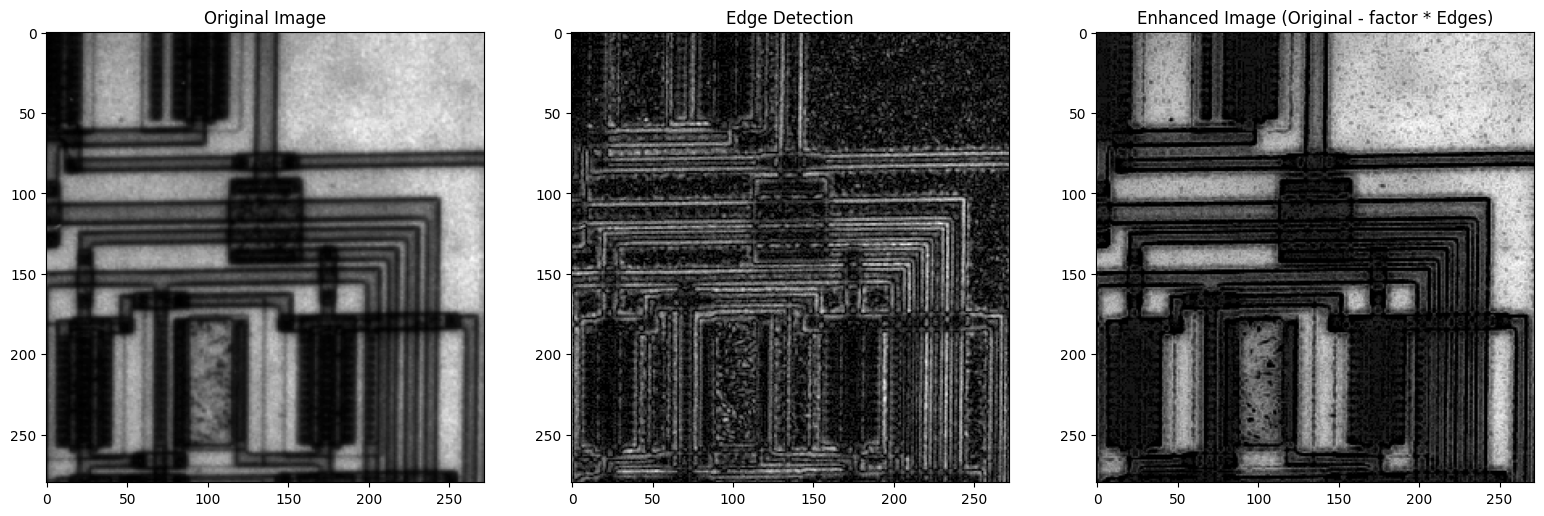

In [11]:
'''
Optional
1-Make edge detection
2-Multiply by factor < 1
3-Subtract (Orginal Image) - (Edge Detection Image)
'''

edge_image = np.abs(log1_thresh)

factor = 0.5  

img_normalized = img / 255.0 if img.max() > 1 else img
edge_normalized = edge_image / edge_image.max()

enhanced_image = img_normalized - (factor * edge_normalized)
enhanced_image = np.clip(enhanced_image, 0, 1)

show_images([img, edge_image, enhanced_image],
            ['Original Image', 'Edge Detection', 'Enhanced Image (Original - factor * Edges)'])
